In [1]:
from langchain_core.tools import Tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import SystemMessage, HumanMessage

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI

from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Annotated, Literal
from typing import List
from dotenv import load_dotenv

load_dotenv()

True

In [91]:
import os

In [60]:
web_search = TavilySearchResults(max_results=2)

In [3]:
results=web_search.invoke("US-Iran Talk latest news")

In [6]:
for result in results:
    print(result['content'],"\n------------------------------------------------------------")

... news & analysis, up ... The U.S. team negotiating with Iran is 'out of their league' and uninterested in diplomacy: Expert. 
------------------------------------------------------------
Iran's state media has said Tehran has "no plans for now to participate" in the second round of negotiations with the US about the war, 
------------------------------------------------------------


In [7]:
queries = ["US-Iran Talk latest news", "Role of Pakistan in US-Iran Peace Talk"]
web_results = []
for query in queries:
    results = web_search.invoke(query)
    for result in results:
        web_results.append(result['content'])

In [8]:
context = "\n".join(web_results)
print(type(context))

<class 'str'>


In [94]:
# llm_gemini= ChatGoogleGenerativeAI(model="gemini-2.5-flash")
# llm_gemini.invoke("hi")

In [95]:
groq_llm = ChatGroq(model="openai/gpt-oss-20b")
groq_llm.invoke("hi").content

'Hello! How can I help you today?'

In [96]:
class Outlines(BaseModel):
    Sections: List[str] = Field(description="What should be the main sections for this topic to research")

In [98]:
class Evaluation(BaseModel):
    improvement_needed: Literal["yes","no"] =Field(description="check whether improvement in given paper is needed or not")
    feedback: str = Field(description="feedback about which sections should improve and need what improvements")

In [99]:
class Queries(BaseModel):
    queries: List[str] =Field(description="Give multiple queries for specific given topic to do web search for getting context to write a research paper for given topic")

In [100]:
class GraphState(TypedDict):
    topic: str
    queries: Queries
    context: str
    Sections: Outlines
    paper: str
    evaluation: Evaluation

In [101]:
llm_queries = groq_llm.with_structured_output(Queries)
def query_generator(state: GraphState):
    topic = state['topic']
    Query_SYS_Prompt = """You are an expert in generating multiple queries for a given topic.
                    Against these queries there will be web search to get context for this topic. 
                    So, give list of 3-6 Queries for getting relevant info for given topic, to write a research paper on this topic."""
                    
    response = llm_queries.invoke(
        [
            SystemMessage(content=Query_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}")
        ]
    )
    
    return {"queries": response}

In [102]:
from langchain_core.runnables import RunnableParallel

In [104]:
def web_search1(queries):
    result1 = []
    results = web_search.invoke(queries[0])
    for res in results:
        result1.append(res['content'])
    return {"result1": result1}
        
def web_search2(queries):
    result2 = []
    results = web_search.invoke(queries[1])
    for res in results:
        result2.append(res['content'])
    return {"result2": result2}
        
def web_search3(queries):
    result3 = []
    results = web_search.invoke(queries[2])
    for res in results:
        result3.append(res['content'])
    return {"result3": result3}
        
def web_search4(queries):
    result4 = []
    results = web_search.invoke(queries[3])
    for res in results:
        result4.append(res['content'])
    return {"result4": result4}
        
def web_search5(queries):
    result5 = []
    results = web_search.invoke(queries[4])
    for res in results:
        result5.append(res['content'])
    return {"result5": result5}

In [105]:
parallel_search = RunnableParallel(
    search1 = web_search1,
    search2 = web_search2,
    search3 = web_search3,
    search4 = web_search4,
    search5 = web_search5
)

In [117]:
def webSearch(state: GraphState):
    queries_list = state['queries'].queries
    web_result = []
    
    result = parallel_search.invoke(queries_list)
    result1 = result['search1']['result1']
    result2 = result['search2']['result2']
    result3 = result['search3']['result3']
    result4 = result['search4']['result4']
    result5 = result['search5']['result5']
    
    web_result.extend(result1)
    web_result.extend(result2)
    web_result.extend(result3)
    web_result.extend(result4)
    web_result.extend(result5)
    
    context = "\n".join(str(item) for item in web_result)
    
    return {"context": context}

In [73]:
# def webSearch(state: GraphState):
#     queries_list = state['queries'].queries
    
#     web_results = []
    
#     for query in queries_list:
#         results = web_search.invoke(query)
#         for result in results:
#             web_results.append(result['content'])
            
#     context = "\n".join(web_results)
    
#     return {"context": context}

In [118]:
llm_with_planning = groq_llm.with_structured_output(Outlines)

def planner(state: GraphState):
    topic = state['topic']
    context = state['context']
    
    planner_SYS_Prompt = """You are an expert in planning that what should be the sections for a research paper based on given topic and web-searched context. 
    You will be given topic upon which there will be written research paper, and also web-searched context will be given so that based on these you give main-haeadings that are sections and also reason and idea what should be in these sections.
    SO always, give list of main sections based on that the writer will compose a research paper for given topic, always keep in mind topic and given web-searched context for giving sections for research paper"""
    
    response = llm_with_planning.invoke(
        [
            SystemMessage(content=planner_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}\n\nContext: {context}")
        ]
    )
    
    return {"Sections": response}

In [119]:
def writer(state: GraphState):
    topic = state['topic']
    sections = state['Sections'].Sections
    context = state['context']
    
    writer_SYS_Prompt = """You are an expert in writing a concise research paper for a given topic of interest. 
    You will be given topic, web-searched context and the main sections based on that you have to write a concise research paper for given topic. 
    The research paper should be accurate, complete and cover all given sections with well detail, so that paper looks great to read and clears everything about this topic. 
    NOTE: Always give complete research paper like a professional one, nothing extra than paper itself"""
    
    paper = groq_llm.invoke(
        [
            SystemMessage(content=writer_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}\n\n Context: {context}\n\nMain Sections for paper: {sections}")
        ]
    )
    
    return {"paper":paper.content}

In [120]:
evaluation_llm = groq_llm.with_structured_output(Evaluation)

def evaluator(state: GraphState):
    topic = state['topic']
    context = state['context']
    paper = state['paper']
    
    Evaluator_SYS_Prompt = """You are an expert in evaluating a research paper. 
    You will be topic, web-searched context and paper. You have to carefully evaluate paper based on completeness, accurateness, conciseness and no-harmness.
    If you realize, improvement is needed then set improvement_needed='yes' otherwise 'no'. 
    And also provide feedback if needed for improvement, state which section needed improvement and what improvements should be implemented."""
    
    evaluation = evaluation_llm.invoke(
        [
            SystemMessage(content=Evaluator_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}\n\nContext: \n{context}\n\nResearch Paper: \n{paper}")
        ]
    )
    
    return {"evaluation": evaluation}

In [121]:
def router(state: GraphState):
    improvement_needed = state['evaluation'].improvement_needed
    
    if improvement_needed == 'yes':
        return "improvement_needed"
    else:
        return "not_needed"

In [122]:
def rewriter(state: GraphState):
    topic = state['topic']
    context = state['context']
    paper = state['paper']
    feedback = state['evaluation'].feedback
    
    rewriter_SYS_Prompt = """You are an expert rewriter agent that rewrites given research paper based on feedback. 
    You will be given topic for research, web-searched context, original research paper that is based on topic and also feeback for paper will be given. 
    You have to rewrite this research paper concisely based on given feedback in scuh a way that it follows all improvement and looks complete and accurate. 
    always based on feedback rewrite paper. never mention based on feedback or any thing else in paper.
    NOTE: Always give complete research paper like a professional one, nothing extra than paper itself"""
    
    research_paper = groq_llm.invoke(
        [
            SystemMessage(content=rewriter_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}\n\nOriginal Paper: \n\n{paper}\n\nFeedback on paper: \n{feedback}")
        ]
    )
    
    return {"paper": research_paper.content}

In [123]:
def downable_html(state: GraphState):
    paper = state['paper']
    
    with open("paper", 'w') as file:
        file.write(paper)
        
    return {"paper": paper}

In [124]:
builder = StateGraph(GraphState)

In [125]:
builder.add_node("query_generator", query_generator)
builder.add_node("webSearch", webSearch)
builder.add_node("planner", planner)
builder.add_node("writer", writer)
builder.add_node("evaluator", evaluator)
builder.add_node("rewriter", rewriter)
builder.add_node("downable_html", downable_html)

builder.add_edge(START, "query_generator")
builder.add_edge("query_generator", "webSearch")
builder.add_edge("webSearch", "planner")
builder.add_edge("planner", "writer")
builder.add_edge("writer", "evaluator")
builder.add_conditional_edges(
    "evaluator",
    router,
    {
        "not_needed": "downable_html",
        "improvement_needed": "rewriter"
    }
)
builder.add_edge("rewriter", "evaluator")
builder.add_edge("downable_html", END)

graph = builder.compile()

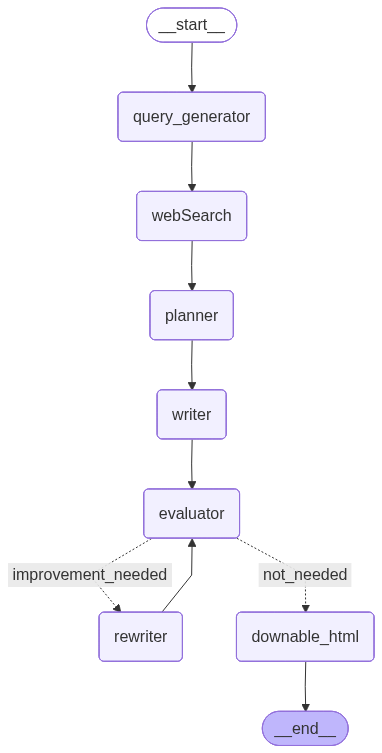

In [126]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
graph.invoke({"topic":"Latest Last week AI updates"})

{'topic': 'Latest Last week AI updates',
 'queries': Queries(queries=['AI news and updates last week', 'Recent AI breakthroughs and publications November 2023', 'Top AI research papers published last week', 'Latest developments in machine learning this week', 'AI industry news from the past week', 'Recent AI conferences and workshops results last week']),
 'context': 'AI Leaders Council\n\n# AI Insiders Weekly: Top Stories from April 13–19, 2026\n\nApr 20, 2026 | AI News\n\nThis week’s developments highlight a clear evolution in enterprise AI. Organizations are no longer focused on access to AI tools, but on how to scale usage responsibly, embed AI into workflows, and translate adoption into measurable outcomes. The most relevant stories center on governance gaps, workforce behavior, and practical deployment patterns across industries.\n\n## 1. The State of AI Talent 2026: How Organizations Are Building, Scaling, and Adapting the AI Workforce (Survey)\n\nTake the survey\n\n## 2. AI ado

In [127]:
for event in graph.stream({"topic":"The impact of AI on medicine"}):
    node = list(event.keys())[0]
    
    print(f"\n⚙️ Running: {node}")
    
    if "content" in event[node]:
        print(event[node]["content"], end="", flush=True)
    else:
        print(event.values())


⚙️ Running: query_generator
dict_values([{'queries': Queries(queries=['Impact of artificial intelligence on medical diagnosis accuracy', 'Applications of AI in personalized medicine and treatment plans', 'Ethical considerations of AI deployment in healthcare settings', 'AI-driven drug discovery and development pipeline', 'Role of AI in improving patient outcomes and healthcare efficiency', 'Regulatory challenges and policy frameworks for AI in medicine'])}])

⚙️ Running: webSearch
dict_values([{'context': "Artificial intelligence (AI) has revolutionized medical diagnostics by enhancing efficiency, improving accuracy, and reducing variability. By alleviating the workload of medical staff, AI addresses challenges such as increasing diagnostic demands, workforce shortages, and reliance on subjective interpretation. This review examines the role of AI in reducing diagnostic workload and enhancing efficiency across medical fields from January 2019 to February 2024, identifying limitations 

BadRequestError: Error code: 400 - {'error': {'message': 'Failed to parse tool call arguments as JSON', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"name": "Evaluation", "arguments": {"feedback":"The paper is comprehensive but could benefit from several improvements:\\n1. **Methods – Search Strategy & Study Selection**: Provide the exact search strings for each database, include the number of hits per database, and clarify how duplicates were handled. Add a PRISMA flow diagram caption and reference the figure.\\n2. **Risk of Bias Assessment**: Summarize QUADAS‑2 and RoB‑2 results in a concise table, and explain how high‑risk studies were handled in sensitivity analyses.\\n3. **Meta‑analysis Details**: Specify the statistical software used, the exact random‑effects model (e.g., Restricted Maximum Likelihood), and how heterogeneity was explored beyond I² (e.g., meta‑regression).\\n4. **Workforce Modelling**: Clearly state the assumptions, provide th